In [1]:
# mlp_monomial_fit.py
from __future__ import annotations
from dataclasses import dataclass, field
from typing import Tuple, Literal, Optional

import jax
import jax.numpy as jnp
from jax import random
from flax import nnx
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

# ------------------------------
# Utilities: nodes & numerics
# ------------------------------
def cheb_nodes(N: int) -> jnp.ndarray:
    """Chebyshev–Lobatto nodes on [-1,1]: x_j = cos(pi*j/(N-1)), j=0..N-1"""
    j = jnp.arange(N, dtype=jnp.float64)
    return jnp.cos(jnp.pi * j / (N - 1))

def local_spacings(x: jnp.ndarray) -> jnp.ndarray:
    """Local grid spacing per point (use min neighbor distance)."""
    # x is descending for cheb_nodes; spacings are positive magnitudes
    dx = jnp.abs(jnp.diff(x))
    # endpoints: use nearest spacing; interior: min of left/right
    left = jnp.concatenate([dx[:1], dx])
    right = jnp.concatenate([dx, dx[-1:]])
    return jnp.minimum(left, right)

def whiten_columns(Phi: jnp.ndarray, eps: float = 1e-18) -> Tuple[jnp.ndarray, jnp.ndarray, jnp.ndarray]:
    """Column-wise standardization: (Phi - mu) / std."""
    mu = jnp.mean(Phi, axis=0)
    std = jnp.std(Phi, axis=0) + eps
    Phi_w = (Phi - mu) / std
    return Phi_w, mu, 1.0 / std

def ridge_solve_svd(Phi: jnp.ndarray, y: jnp.ndarray, lam: float) -> jnp.ndarray:
    """
    Solve min_c ||Phi c - y||^2 + lam ||c||^2 using SVD.
    Returns c of shape [m].
    """
    U, S, Vh = jnp.linalg.svd(Phi, full_matrices=False)
    # c = V diag(S/(S^2+lam)) U^T y
    Uy = U.T @ y
    w = (S / (S * S)) * Uy
    c = (Vh.T) @ w
    return c

# ------------------------------
# Activations
# ------------------------------
def act_apply(name: Literal["tanh", "silu", "exp", "sin"], z: jnp.ndarray) -> jnp.ndarray:
    if name == "tanh":
        return jnp.tanh(z)
    elif name == "silu":
        # SiLU(x) = x * sigmoid(x)
        return jax.nn.silu(z)
    elif name == "exp":
        # Guard against overflow; whitening will remove bias from clipping
        return jnp.exp(jnp.clip(z, -20.0, 20.0))
    elif name == "sin":
        return jnp.sin(z)
    else:
        raise ValueError(f"Unknown activation: {name}")

# ------------------------------
# Feature generators
# ------------------------------
@dataclass
class SmoothFeatureConfig:
    width: int = 512
    slope_gain: float = 2.0  # higher = steeper transitions; scaled by local spacing
    max_abs_slope: float = 50.0  # cap to avoid saturation/collinearity

def build_smooth_params(x_train: jnp.ndarray, cfg: SmoothFeatureConfig) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Option 1: Chebyshev-friendly features for smooth activations (tanh/silu/exp).
    Place centers at (a,b) so that each unit transitions near a grid node with
    slope magnitude ~ slope_gain / local_spacing, capped by max_abs_slope.
    """
    N = x_train.size
    # Use Chebyshev nodes as centers for stability
    t = cheb_nodes(cfg.width)
    # Local spacings measured on training grid to set a sensible scale
    h = local_spacings(x_train)
    h_eff = jnp.median(h)  # single global scale from grid; robust
    base_slope = cfg.slope_gain / (h_eff + 1e-18)
    a = jnp.clip(jnp.full((cfg.width,), base_slope), -cfg.max_abs_slope, cfg.max_abs_slope)
    # Center each unit around its knot: sigma(a*(x - t_j)) == sigma(a*x + b), with b = -a*t_j
    b = -a * t
    return a, b

@dataclass
class FourierFeatureConfig:
    width: int = 512                # total units; effective pairs ~ width//2
    mode: Literal["deterministic", "rff"] = "deterministic"
    rff_scale: float = 4.0          # std of Gaussian for RFF (in rad per unit-x)
    max_freq: Optional[int] = None  # for deterministic: use {0..max_freq}; auto if None

def build_sinusoid_params(cfg: FourierFeatureConfig, key: jax.Array) -> Tuple[jnp.ndarray, jnp.ndarray]:
    """
    Option 2: sinusoidal features. We realize both sin & cos by setting phases via b.
    Return vectors a (frequencies) and b (phases).
    """
    m = cfg.width
    # We build m//2 frequencies and duplicate with phases 0 (sin) and pi/2 (cos)
    if cfg.mode == "deterministic":
        # Choose consecutive integer frequencies; for [-1,1], these are well-behaved
        K = (m // 2) - 1
        if cfg.max_freq is not None:
            K = min(K, int(cfg.max_freq))
        # include zero frequency (bias via cos phase)
        omegas = jnp.arange(K + 1, dtype=jnp.float64) * jnp.pi  # ω_k = kπ
    elif cfg.mode == "rff":
        nfreq = m // 2
        omegas = cfg.rff_scale * random.normal(key, (nfreq,), dtype=jnp.float64)
        # ensure one zero-freq for bias-like feature
        omegas = omegas.at[0].set(0.0)
    else:
        raise ValueError(f"Unknown Fourier mode {cfg.mode}")

    # Build pairs: sin(ω x + 0), sin(ω x + π/2) == cos(ω x)
    a = jnp.repeat(omegas, 2)
    phases = jnp.tile(jnp.array([0.0, jnp.pi / 2], dtype=jnp.float64), reps=omegas.size)
    b = phases
    # If m is odd, pad one extra sin(0·x) to reach width m
    if a.size < m:
        a = jnp.concatenate([a, jnp.array([0.0])])
        b = jnp.concatenate([b, jnp.array([0.0])])
    return a, b

# ------------------------------
# Fixed-feature 1HL MLP module
# ------------------------------
class OneHiddenFixed(nnx.Module):
    """
    y(x) = sum_i c_i * normalize( sigma(a_i * x + b_i) )
    where normalization is column-wise whitening computed on the training grid.
    """
    a: jnp.ndarray
    b: jnp.ndarray
    mu: jnp.ndarray
    inv_std: jnp.ndarray
    act_name: str
    c: nnx.Param

    def __init__(self, a: jnp.ndarray, b: jnp.ndarray,
                 mu: jnp.ndarray, inv_std: jnp.ndarray,
                 act_name: str, c_init: Optional[jnp.ndarray] = None):
        self.a = a
        self.b = b
        self.mu = mu
        self.inv_std = inv_std
        self.act_name = act_name
        if c_init is None:
            self.c = nnx.Param(jnp.zeros(a.shape[0], dtype=jnp.float64))
        else:
            self.c = nnx.Param(c_init.astype(jnp.float64))

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        """
        x: [...], returns y: [...]
        """
        x = x.astype(jnp.float64)
        z = x[..., None] * self.a[None, ...] + self.b[None, ...]  # broadcast
        h = act_apply(self.act_name, z)
        hw = (h - self.mu) * self.inv_std
        y = hw @ self.c
        return y

# ------------------------------
# Fitter
# ------------------------------
@dataclass
class FitConfig:
    # training grid & target
    n_train: int = 513         # Chebyshev nodes count
    k_power: int = 7           # fit x^k
    # model
    activation: Literal["tanh", "silu", "exp", "sin"] = "tanh"
    smooth_cfg: SmoothFeatureConfig = field(default_factory=SmoothFeatureConfig)
    fourier_cfg: FourierFeatureConfig = field(default_factory=FourierFeatureConfig)
    # solver
    ridge: float = 1e-16

def build_features(x: jnp.ndarray,
                   a: jnp.ndarray, b: jnp.ndarray,
                   act_name: str) -> jnp.ndarray:
    z = x[:, None] * a[None, :] + b[None, :]
    return act_apply(act_name, z)

def fit_monomial_module(cfg: FitConfig,
                        *,
                        key: jax.Array = random.PRNGKey(0)) -> Tuple[OneHiddenFixed, jnp.ndarray, jnp.ndarray]:
    """
    Build features per activation, fit c by SVD-ridge on Chebyshev nodes for target y=x^k.
    Returns:
      model (nnx.Module), training grid x_train, training residuals r = y - yhat
    """
    # Training nodes and target
    x_train = cheb_nodes(cfg.n_train)
    y_train = x_train ** cfg.k_power

    # Parameters (a,b) depending on activation
    if cfg.activation == "sin":
        a, b = build_sinusoid_params(cfg.fourier_cfg, key)
    else:
        a, b = build_smooth_params(x_train, cfg.smooth_cfg)

    # Feature matrix and whitening
    Phi = build_features(x_train, a, b, cfg.activation)
    Phi_w, mu, inv_std = whiten_columns(Phi)

    # Ridge solve (SVD-based)
    c = ridge_solve_svd(Phi_w, y_train, lam=cfg.ridge)

    # Pack module
    model = OneHiddenFixed(a=a, b=b, mu=mu, inv_std=inv_std, act_name=cfg.activation, c_init=c)

    # Training residuals for sanity check
    yhat = (Phi_w @ c)
    r = y_train - yhat

    return model, x_train, r



[tanh] N=2048 m=512 | max|err|=2.969e+00  relL2=3.415e+00


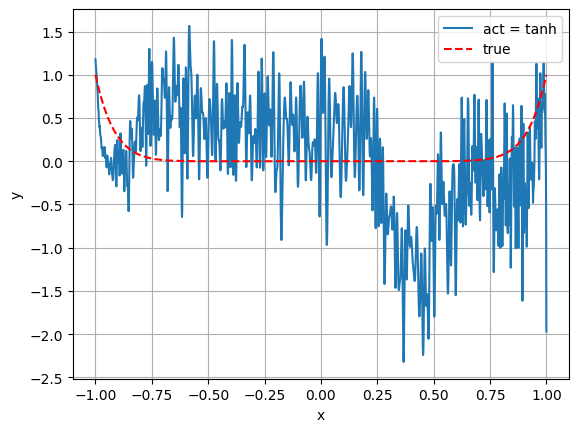

[silu] N=2048 m=512 | max|err|=6.461e+00  relL2=1.242e+00


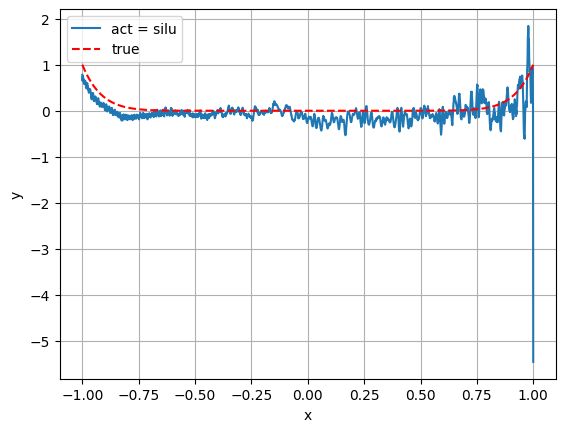

[ exp] N=2048 m=512 | max|err|=2.643e+10  relL2=5.342e+09


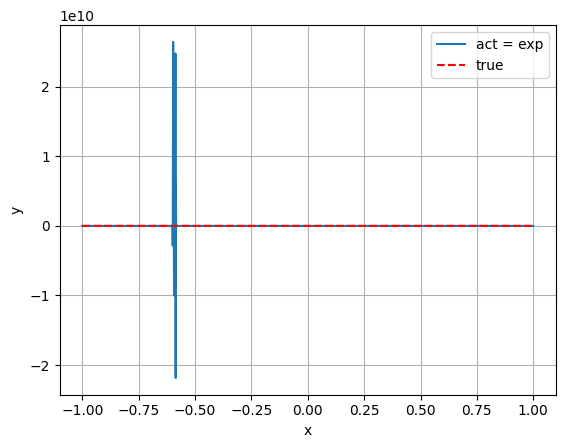

[ sin] N=2048 m=512 | max|err|=3.038e-01  relL2=1.141e+00


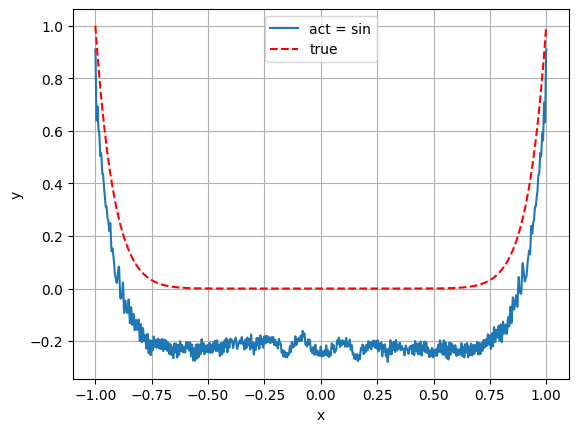

In [ ]:
activations = ["tanh", "silu", "exp", "sin"]

for act in activations:
    if act == "sin":
        fourier = FourierFeatureConfig(width=512, mode="deterministic", max_freq=None)
        cfg = FitConfig(n_train=1025, k_power=9.0, activation=act,
                        fourier_cfg=fourier, ridge=1e-1)
    else:
        smooth = SmoothFeatureConfig(width=512, slope_gain=2.0, max_abs_slope=50.0)
        cfg = FitConfig(n_train=1025, k_power=9.0, activation=act,
                        smooth_cfg=smooth, ridge=1e-12)

    key = random.PRNGKey(42)
    model, xtr, rtr = fit_monomial_module(cfg, key=key)

    # Evaluate on a dense grid for error report
    x_eval = jnp.linspace(-1, 1, 2001, dtype=jnp.float64)
    y_true = x_eval ** cfg.k_power
    y_pred = model(x_eval)
    max_err = jnp.max(jnp.abs(y_pred - y_true))
    rel_l2 = jnp.linalg.norm(y_pred - y_true) / jnp.linalg.norm(y_true + 1e-30)
    print(f"[{act:>4}] N={cfg.n_train} m={ (cfg.fourier_cfg.width if act=='sin' else cfg.smooth_cfg.width) } "
            f"| max|err|={float(max_err):.3e}  relL2={float(rel_l2):.3e}")
    
    plt.plot(x_eval, y_pred, label=f'act = {act}')

    plt.plot(x_eval, y_true, 'r--', label='true')
    plt.legend()
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid()
    plt.show()

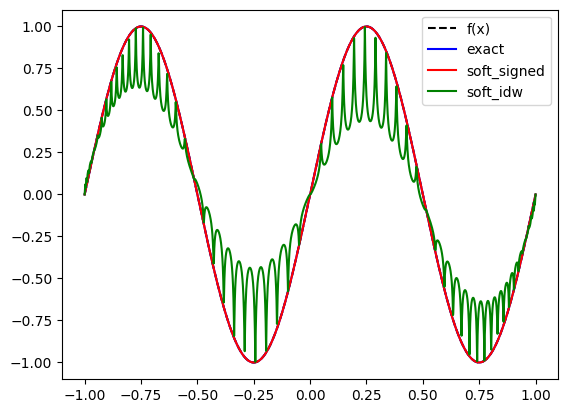

init ‖exact - soft_signed‖_inf = 1.4765966227514582e-14
init ‖exact - soft_idw   ‖_inf = 0.5584408391458286


In [6]:
# barycentric_signed_soft.py
from __future__ import annotations
import jax, jax.numpy as jnp
from flax import nnx
jax.config.update("jax_enable_x64", True)

# -----------------------------
# Chebyshev(2) nodes + weights
# -----------------------------
def cheb2_nodes(n: int) -> jnp.ndarray:
    j = jnp.arange(n + 1, dtype=jnp.float64)
    return jnp.cos(jnp.pi * j / n)

def cheb2_weights(n: int) -> jnp.ndarray:
    j = jnp.arange(n + 1, dtype=jnp.float64)
    delta = jnp.ones_like(j, dtype=jnp.float64).at[0].set(0.5).at[-1].set(0.5)
    return (-1.0) ** j * delta

# -----------------------------
# Exact second barycentric eval
# -----------------------------
def _snap_to_node(x, xj, fj, tol=0.0):
    eq = jnp.isclose(x, xj, rtol=0.0, atol=tol)
    return jnp.any(eq), fj[jnp.argmax(eq)]

def barycentric_second_form(x, xj, fj, wj, snap_tol=0.0):
    x = jnp.asarray(x, jnp.float64)
    xj, fj, wj = map(lambda a: jnp.asarray(a, jnp.float64), (xj, fj, wj))
    def _one(xs):
        hit, val = _snap_to_node(xs, xj, fj, tol=snap_tol)
        def _ratio():
            d = xs - xj
            t = wj / d
            return jnp.sum(t * fj) / jnp.sum(t)
        return jax.lax.cond(hit, lambda: val, _ratio)
    return jax.vmap(_one)(x.reshape(-1)).reshape(x.shape)

# -----------------------------
# Log-domain signed sum helper
# -----------------------------
def _log_signed_sum(logmags: jnp.ndarray, signs: jnp.ndarray):
    """Return (log|sum s_i*e^{a_i}|, sign(sum ...)). Handles the cases when
       all signs are + or all - . logmags, signs are [M]."""
    # Separate groups
    pos_mask = signs > 0.0
    neg_mask = signs < 0.0
    # LSE over groups; if a group is empty, set it to -inf
    def lse_or_ninf(vals, mask):
        masked = jnp.where(mask, vals, -jnp.inf)
        m = jnp.max(masked)
        return jnp.where(jnp.isfinite(m), m + jnp.log(jnp.sum(jnp.where(mask, jnp.exp(masked - m), 0.0))), -jnp.inf)
    Lp = lse_or_ninf(logmags, pos_mask)
    Ln = lse_or_ninf(logmags, neg_mask)

    # If one side empty -> sign is that side
    no_pos = jnp.isneginf(Lp)
    no_neg = jnp.isneginf(Ln)
    def only_pos():
        return Lp, jnp.array(1.0, jnp.float64)
    def only_neg():
        return Ln, jnp.array(-1.0, jnp.float64)

    def both():
        # log(|e^Lp - e^Ln|) with sign = sign(Lp - Ln)
        a = jnp.maximum(Lp, Ln)
        b = jnp.minimum(Lp, Ln)
        log_abs = a + jnp.log1p(-jnp.exp(b - a))  # stable for a>=b
        sgn = jnp.sign(Lp - Ln)
        return log_abs, sgn

    return jax.lax.cond(no_neg, only_pos,
                        lambda: jax.lax.cond(no_pos, only_neg, both))

# -----------------------------
# Signed "soft" rational barycentric
#   magnitudes:  exp(b_j - tau*log(|x-x_j|+eps))
#   signs:
#     Den: sign(w_j) * sign(x - x_j)
#     Num: Den * sign(f_j)
# For tau=1, b_j=log|w_j|, eps->0 this equals the exact barycentric.
# -----------------------------
class SignedSoftBarycentric(nnx.Module):
    def __init__(self, rngs: nnx.Rngs, xj, fj, wj, eps: float = 1e-15, tau_init: float = 1.0):
        self.xj = jnp.asarray(xj, jnp.float64)
        self.fj = jnp.asarray(fj, jnp.float64)
        self.wj = jnp.asarray(wj, jnp.float64)
        self.eps = float(eps)
        # trainables
        self.tau = nnx.Param(jnp.array(tau_init, jnp.float64))
        self.b   = nnx.Param(jnp.log(jnp.abs(self.wj) + 0.0))  # magnitude only

    def _eval_one(self, xs: jnp.float64):
        # Snap to node first
        hit, val = _snap_to_node(xs, self.xj, self.fj, tol=0.0)
        if_true  = lambda: val

        def if_false():
            d  = xs - self.xj
            ad = jnp.abs(d) + self.eps

            # Base log-magnitude (shared):
            base = self.b - self.tau * jnp.log(ad)

            # Denominator
            s_den = jnp.sign(self.wj) * jnp.sign(d)
            Lden, sgn_den = _log_signed_sum(base, s_den)

            # Numerator (include |f_j| in magnitude and its sign)
            s_num = s_den * jnp.sign(self.fj)
            Lnum, sgn_num = _log_signed_sum(base + jnp.log(jnp.abs(self.fj) + 0.0), s_num)

            # Ratio
            y = (sgn_num * sgn_den) * jnp.exp(Lnum - Lden)
            return y

        return jax.lax.cond(hit, if_true, if_false)

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, jnp.float64)
        y = jax.vmap(self._eval_one)(x.reshape(-1))
        return y.reshape(x.shape)

# -----------------------------
# (Optional) Positive-weight IDW/softmax readout (clarified)
# -----------------------------
class IDWReadout(nnx.Module):
    """Positive normalized weights (no signs). Not a polynomial interpolant."""
    def __init__(self, rngs: nnx.Rngs, xj, fj, wj, eps: float = 1e-15, tau_init: float = 1.0):
        self.xj = jnp.asarray(xj, jnp.float64)
        self.fj = jnp.asarray(fj, jnp.float64)
        self.eps = float(eps)
        self.tau = nnx.Param(jnp.array(tau_init, jnp.float64))
        # magnitude of classical weights as a sensible bias init
        self.b   = nnx.Param(jnp.log(jnp.abs(jnp.asarray(wj, jnp.float64)) + 0.0))

    def __call__(self, x: jnp.ndarray) -> jnp.ndarray:
        x = jnp.asarray(x, jnp.float64)
        d = jnp.abs(x[..., None] - self.xj[None, ...]) + self.eps
        logits = self.b[None, ...] - self.tau * jnp.log(d)
        alpha = jax.nn.softmax(logits, axis=-1)
        return jnp.sum(alpha * self.fj[None, :], axis=-1)

# -----------------------------
# Convenience wrapper
# -----------------------------
class BarycentricReadout(nnx.Module):
    def __init__(self, rngs: nnx.Rngs, xj, fj, wj, soft_eps=1e-15):
        self.xj = jnp.asarray(xj, jnp.float64)
        self.fj = jnp.asarray(fj, jnp.float64)
        self.wj = jnp.asarray(wj, jnp.float64)
        self.exact = lambda x: barycentric_second_form(x, self.xj, self.fj, self.wj, snap_tol=0.0)
        self.soft_signed = SignedSoftBarycentric(rngs, xj, fj, wj, eps=soft_eps, tau_init=1.0)
        self.soft_idw    = IDWReadout(rngs, xj, fj, wj, eps=soft_eps, tau_init=1.0)

    def __call__(self, x):         # default: exact
        return self.exact(x)

# -----------------------------
# Smoke test
# -----------------------------
if __name__ == "__main__":
    key = jax.random.PRNGKey(0)
    n = 64
    xj = cheb2_nodes(n)
    wj = cheb2_weights(n)
    f  = lambda x: jnp.sin(2.0 * jnp.pi * x)   # your example
    fj = f(xj)

    rngs = nnx.Rngs(key)
    readout = BarycentricReadout(rngs, xj, fj, wj)

    xx = jnp.linspace(-1.0, 1.0, 2001)
    y_exact = readout.exact(xx)
    y_soft_signed = readout.soft_signed(xx)
    y_soft_idw = readout.soft_idw(xx)

    plt.plot(xx, f(xx), 'k--', label="f(x)")
    plt.plot(xx, y_exact, 'b-', label="exact")
    plt.plot(xx, y_soft_signed, 'r-', label="soft_signed")
    plt.plot(xx, y_soft_idw, 'g-', label="soft_idw")
    plt.legend()
    plt.show()

    print("init ‖exact - soft_signed‖_inf =", float(jnp.max(jnp.abs(y_exact - y_soft_signed))))
    print("init ‖exact - soft_idw   ‖_inf =", float(jnp.max(jnp.abs(y_exact - y_soft_idw))))
